# Import Library

In [19]:
import os
import numpy as np
import tensorflow as tf
import random
import shutil
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')

from collections import Counter
from PIL import Image, UnidentifiedImageError,ImageEnhance

# Konfigurasi Path

In [20]:
dataset_path = '../raw_data'  
output_path = '../data_clean'
# Buat folder output jika belum ada
os.makedirs(output_path, exist_ok=True)
# Ukuran untuk MobileNetV2
IMG_WIDTH, IMG_HEIGHT = 224, 224

# Load Dataset

In [21]:
# Daftar kelas pada dataset
classes = os.listdir(dataset_path)
# Fungsi untuk menghitung data yang ada di dalam folder dataset
def count_images_in_folder(dataset_path):
    image_extensions = ['.jpg', '.jpeg', '.png', '.gif', '.bmp']
    count = 0
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if any(file.endswith(ext) for ext in image_extensions):
                count += 1
    return count

total_images = count_images_in_folder(dataset_path)

# Melihat data yang ada di dalam folder
print('Kelas:', classes)
print('Jumlah kelas:', len(classes))
print(f'Jumlah gambar dalam folder: {total_images}')

Kelas: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Jumlah kelas: 4
Jumlah gambar dalam folder: 6400


# EDA (Eksplorasi Dataset Awal)


📊 EKSPLORASI DATASET AWAL

📈 DISTRIBUSI KELAS:
  MildDemented: 896 gambar
  ModerateDemented: 64 gambar
  NonDemented: 3200 gambar
  VeryMildDemented: 2240 gambar


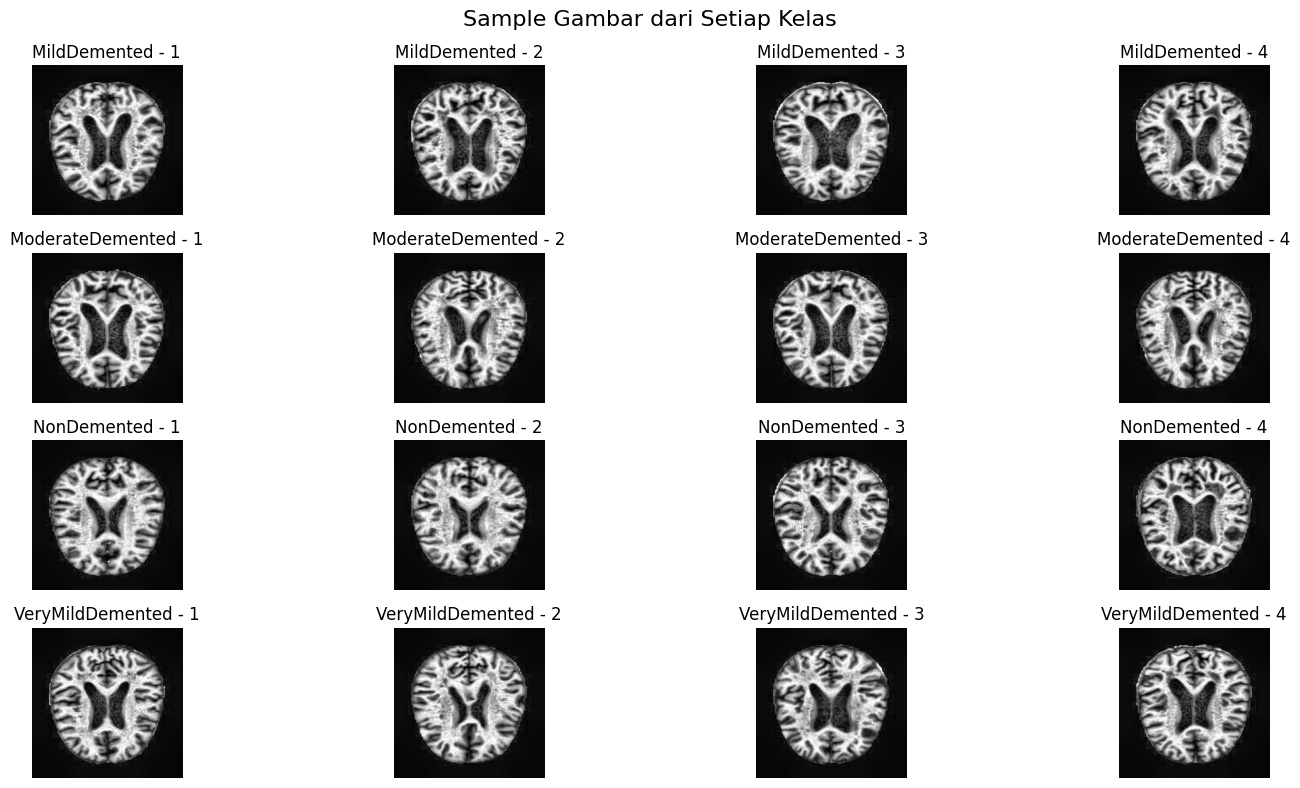

In [22]:
print("\n" + "="*70)
print("📊 EKSPLORASI DATASET AWAL")
print("="*70)

# Analisis distribusi kelas
print("\n📈 DISTRIBUSI KELAS:")
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        n_images = len([f for f in os.listdir(class_path) 
                       if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))])
        print(f"  {class_name}: {n_images} gambar")

# Cek sample gambar dari setiap kelas
fig, axes = plt.subplots(4, 4, figsize=(16, 8))
fig.suptitle('Sample Gambar dari Setiap Kelas', fontsize=16)

for i, class_name in enumerate(classes[:4]):  # Ambil 2 kelas pertama
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:4]
        
        for j, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i, j].imshow(img_rgb)
                axes[i, j].set_title(f'{class_name} - {j+1}')
                axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Cleaning Data

In [23]:
def clean_data(dataset_path, classes):
    corrupted_count = 0
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)  # Coba buka gambar
                img.verify()  # Verifikasi gambar
            except (UnidentifiedImageError, IOError, OSError):
                print(f"Menghapus gambar corrupt: {img_path}")
                os.remove(img_path)  # Hapus gambar corrupt
                corrupted_count += 1
    return corrupted_count

# Membersihkan data
corrupted = clean_data(dataset_path, classes)
print(f'Data sudah dibersihkan. {corrupted} gambar corrupt dihapus.')


Data sudah dibersihkan. 0 gambar corrupt dihapus.


# CLAHE (Contrast Limited Adaptive Histogram Equalization)


🔧 MENERAPKAN CLAHE (CONTRAST LIMITED ADAPTIVE HISTOGRAM EQUALIZATION)

📁 Memproses kelas: MildDemented
  ✅ 896 gambar diproses dengan CLAHE

📁 Memproses kelas: ModerateDemented
  ✅ 64 gambar diproses dengan CLAHE

📁 Memproses kelas: NonDemented
  ✅ 3200 gambar diproses dengan CLAHE

📁 Memproses kelas: VeryMildDemented
  ✅ 2240 gambar diproses dengan CLAHE

✅ Total gambar diproses: 6400

📊 Membuat visualisasi efek CLAHE...


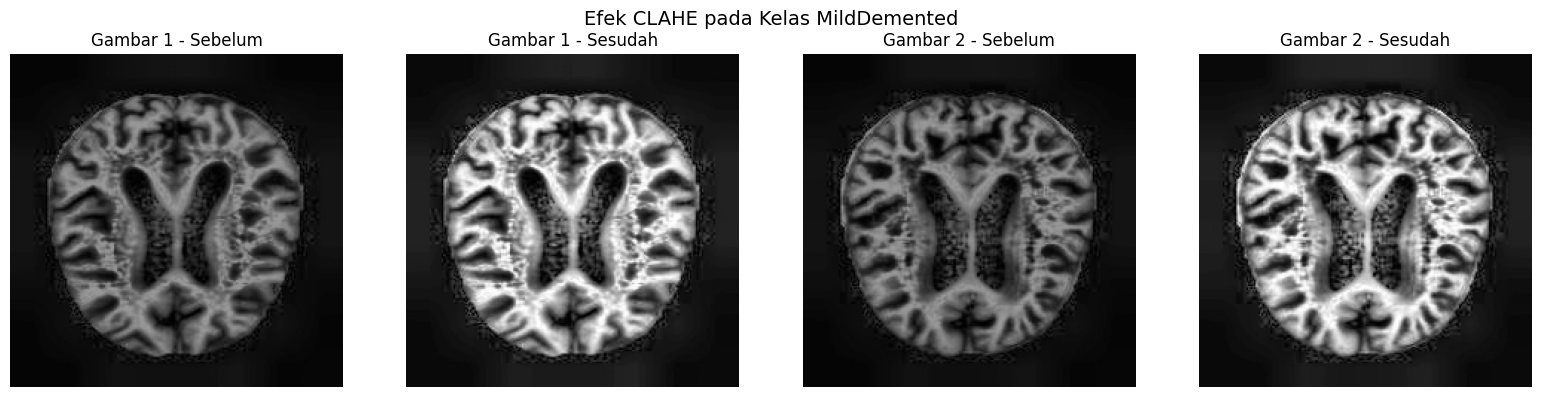

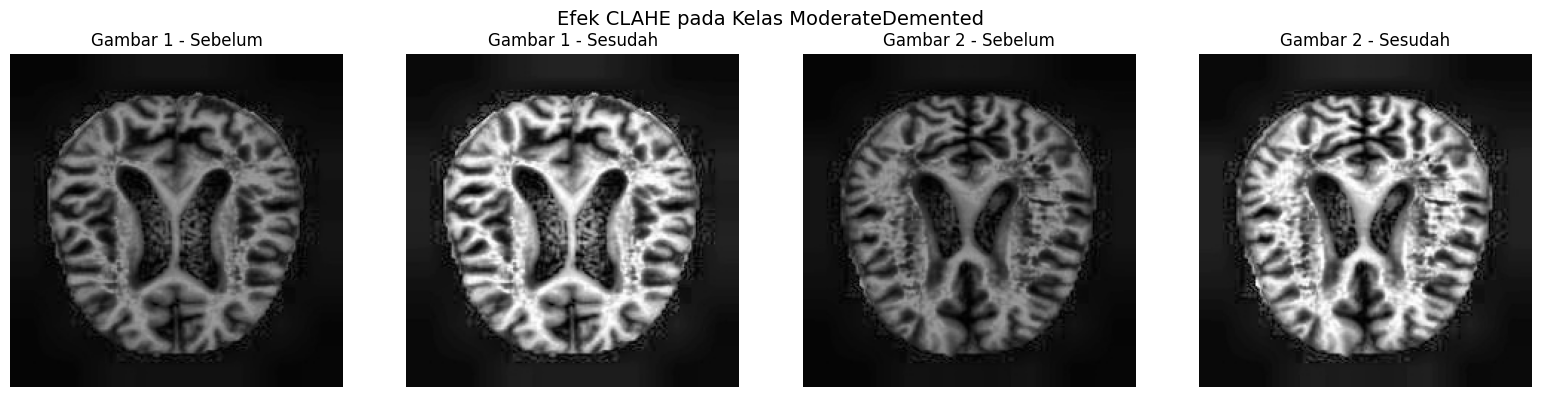

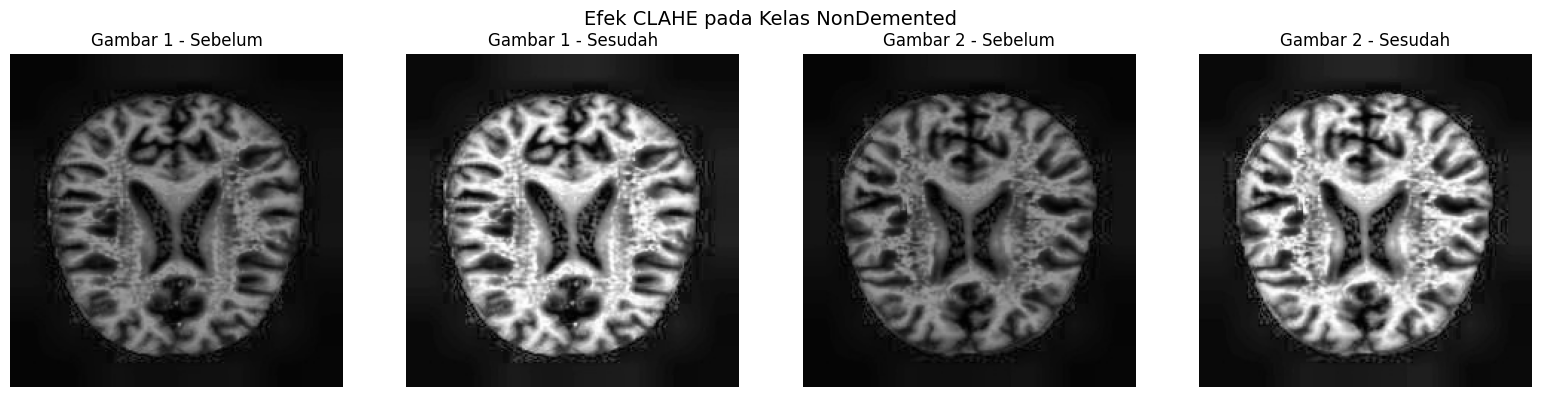

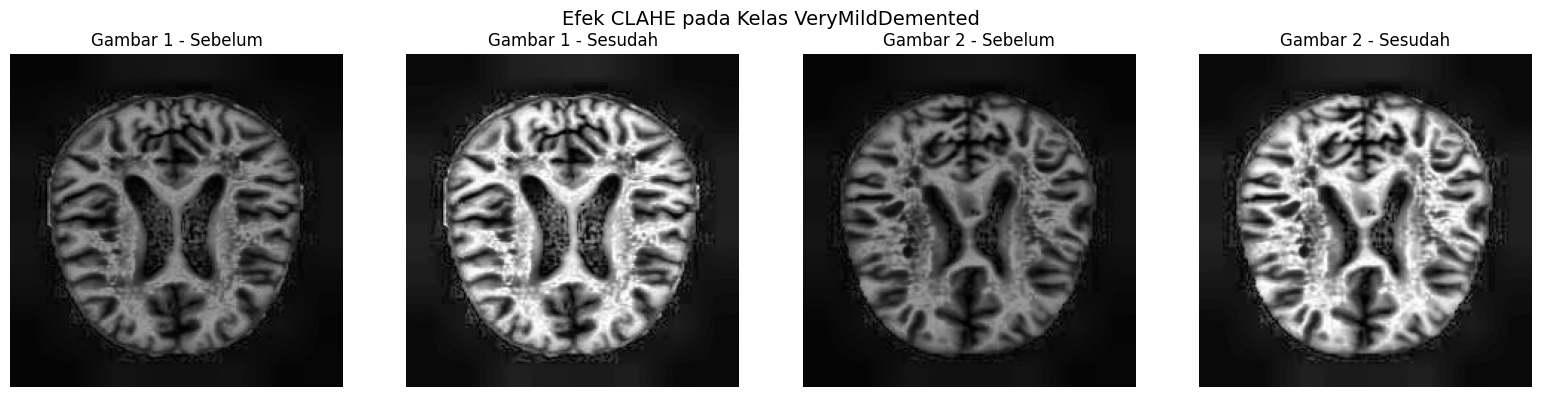

In [24]:
def apply_clahe_to_dataset(dataset_path, classes, clip_limit=2.0, grid_size=(8,8)):
    """
    Meningkatkan kontras citra menggunakan CLAHE
    Sangat penting untuk citra medis seperti X-ray
    """
    print("\n" + "="*70)
    print("🔧 MENERAPKAN CLAHE (CONTRAST LIMITED ADAPTIVE HISTOGRAM EQUALIZATION)")
    print("="*70)
    
    total_processed = 0
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue
            
        print(f"\n📁 Memproses kelas: {class_name}")
        count = 0
        
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            
            # Baca gambar
            img = cv2.imread(img_path)
            if img is None:
                continue
            
            # Konversi ke grayscale
            if len(img.shape) == 3:
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            else:
                gray = img
            
            # Terapkan CLAHE
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
            enhanced = clahe.apply(gray)
            
            # Kembalikan ke 3 channel (RGB)
            enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
            
            # Simpan kembali (overwrite)
            cv2.imwrite(img_path, enhanced_rgb)
            count += 1
            total_processed += 1
        
        print(f"  ✅ {count} gambar diproses dengan CLAHE")
    
    print(f"\n✅ Total gambar diproses: {total_processed}")

    # Visualisasi efek CLAHE
def visualize_clahe_effect():
    """Menampilkan perbedaan sebelum dan sesudah CLAHE"""
    print("\n📊 Membuat visualisasi efek CLAHE...")
    
    # Buat figure terpisah untuk setiap kelas
    for class_name in classes[:4]:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue
            
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(f'Efek CLAHE pada Kelas {class_name}', fontsize=14)
        
        images = os.listdir(class_path)[:2]  # Ambil 2 gambar
        
        for j, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            
            # Baca gambar setelah CLAHE
            img_after = cv2.imread(img_path)
            if img_after is None:
                continue
            img_after_rgb = cv2.cvtColor(img_after, cv2.COLOR_BGR2RGB)
            
            # Simulasi sebelum CLAHE
            gray = cv2.cvtColor(img_after, cv2.COLOR_BGR2GRAY)
            gray_low = cv2.addWeighted(gray, 0.6, np.zeros_like(gray), 0, 0)
            before_rgb = cv2.cvtColor(gray_low, cv2.COLOR_GRAY2RGB)
            
            # Tampilkan
            axes[j*2].imshow(before_rgb)
            axes[j*2].set_title(f'Gambar {j+1} - Sebelum')
            axes[j*2].axis('off')
            
            axes[j*2+1].imshow(img_after_rgb)
            axes[j*2+1].set_title(f'Gambar {j+1} - Sesudah')
            axes[j*2+1].axis('off')
        
        plt.tight_layout()
        plt.show()

# Jalankan CLAHE
apply_clahe_to_dataset(dataset_path, classes)
visualize_clahe_effect()

# Resize Gambar ke 224x224

In [ ]:
# Ukuran gambar yang diinginkan
img_width, img_height = 224, 224

# Fungsi untuk resize gambar
def resize_images(dataset_path, classes, img_width, img_height):
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img = img.resize((img_width, img_height))  
                img.save(img_path)  
            except Exception as e:
                print(f"Error resize {img_path}: {e}")

# Resize gambar
resize_images(dataset_path, classes, img_width, img_height)
print('Resize Gambar Selesai')

Resize Gambar Selesai


# Normalisasi Pixel

In [26]:
def normalize_pixel_values(dataset_path, classes):
    """
    Normalisasi nilai pixel ke range [0,1] untuk model deep learning
    """
    print("\n" + "="*70)
    print("🔧 NORMALISASI PIXEL KE RANGE [0,1]")
    print("="*70)
    
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue
            
        print(f"\n📁 Memproses kelas: {class_name}")
        count = 0
        
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            
            # Baca gambar
            img = cv2.imread(img_path)
            if img is None:
                continue
            
            # Normalisasi ke float [0,1]
            img_float = img.astype(np.float32) / 255.0
            
            # Simpan kembali sebagai uint8 (0-255)
            # Catatan: saat training nanti, akan dinormalisasi lagi
            img_uint8 = (img_float * 255).astype(np.uint8)
            cv2.imwrite(img_path, img_uint8)
            count += 1
        
        print(f"  ✅ {count} gambar dinormalisasi")
    
    print("\n📌 Catatan: Pixel values sekarang di range [0,255] dan siap dinormalisasi saat training")

normalize_pixel_values(dataset_path, classes)


🔧 NORMALISASI PIXEL KE RANGE [0,1]

📁 Memproses kelas: MildDemented
  ✅ 896 gambar dinormalisasi

📁 Memproses kelas: ModerateDemented
  ✅ 64 gambar dinormalisasi

📁 Memproses kelas: NonDemented
  ✅ 3200 gambar dinormalisasi

📁 Memproses kelas: VeryMildDemented
  ✅ 2240 gambar dinormalisasi

📌 Catatan: Pixel values sekarang di range [0,255] dan siap dinormalisasi saat training


# Balance Dataset

In [27]:
target_images_per_class = 3000  # Default 500, sesuaikan

# Fungsi untuk menyamakan jumlah gambar per kelas TANPA augmentasi
def balance_dataset(dataset_path, output_path, classes, target_images_per_class):
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue
            
        output_class_path = os.path.join(output_path, class_name)
        if not os.path.exists(output_class_path):
            os.makedirs(output_class_path)
        
        # List semua gambar di folder kelas
        images = [f for f in os.listdir(class_path) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))]
        num_images = len(images)
        
        print(f"Kelas {class_name} memiliki {num_images} gambar. Target: {target_images_per_class}")
        
        # Jika jumlah gambar kurang dari target
        if num_images < target_images_per_class:
            print(f"  Melakukan duplikasi...")
            # Salin semua gambar asli terlebih dahulu
            for img_name in images:
                img_path = os.path.join(class_path, img_name)
                shutil.copy(img_path, os.path.join(output_class_path, img_name))
            
            # Buat duplikat dari gambar yang ada sampai mencapai target
            num_duplicates = target_images_per_class - num_images
            for i in range(num_duplicates):
                img_name = random.choice(images)
                img_path = os.path.join(class_path, img_name)
                # Dapatkan nama file tanpa ekstensi
                base_name = os.path.splitext(img_name)[0]
                ext = os.path.splitext(img_name)[1]
                new_img_name = f"{base_name}_dup{i}{ext}"
                new_img_path = os.path.join(output_class_path, new_img_name)
                shutil.copy(img_path, new_img_path)
        
        # Jika jumlah gambar lebih dari target
        elif num_images > target_images_per_class:
            print(f"  Mengurangi jumlah gambar (random sampling)...")
            images_to_keep = random.sample(images, target_images_per_class)
            for img_name in images_to_keep:
                img_path = os.path.join(class_path, img_name)
                shutil.copy(img_path, os.path.join(output_class_path, img_name))
        
        # Jika jumlah gambar sudah pas dengan target
        else:
            print(f"  Jumlah sudah sesuai, menyalin gambar...")
            for img_name in images:
                img_path = os.path.join(class_path, img_name)
                shutil.copy(img_path, os.path.join(output_class_path, img_name))
        
        # Hitung hasil akhir
        final_count = len([f for f in os.listdir(output_class_path) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))])
        print(f"  ✅ Hasil akhir: {final_count} gambar")

# Menyamakan jumlah gambar per kelas
balance_dataset(dataset_path, output_path, classes, target_images_per_class)

print("\nProses penyamaan jumlah gambar selesai!")

Kelas MildDemented memiliki 896 gambar. Target: 3000
  Melakukan duplikasi...
  ✅ Hasil akhir: 3000 gambar
Kelas ModerateDemented memiliki 64 gambar. Target: 3000
  Melakukan duplikasi...
  ✅ Hasil akhir: 3000 gambar
Kelas NonDemented memiliki 3200 gambar. Target: 3000
  Mengurangi jumlah gambar (random sampling)...
  ✅ Hasil akhir: 3000 gambar
Kelas VeryMildDemented memiliki 2240 gambar. Target: 3000
  Melakukan duplikasi...
  ✅ Hasil akhir: 3000 gambar

Proses penyamaan jumlah gambar selesai!
